In [1]:
import numpy as np
import matplotlib.pyplot as plt
import visualization
from scipy.stats import norm

import scipy.stats as si
import sympy as sy
from sympy.stats import Normal, cdf

from scipy.stats import multivariate_normal as mvn
from scipy.optimize import minimize

# American Options

In [2]:
def EurCall(So, K, r, v, T, n):
    dt = T/n

    u = np.exp(v*np.sqrt(dt))
    d = 1/u
    p = (np.exp(r*dt)-d)/(u-d)

    # Stock.
    stock = np.zeros((n+1, n+1))
    stock[0, 0] = So

    # Create tree So
    for i in range(1, n+1):
        stock[i, 0] = stock[i-1, 0]*u
        for j in range(1, i+1):
            stock[i, j] = stock[i-1, j-1]*d

    # option Value
    option = np.zeros((n+1, n+1))

    # Last nodes
    for k in range(n+1):
        option[n, k] = max(stock[n, k]-K, 0)

    # Middle nodes
    for i in range(n-1, -1, -1):
        for j in range(i+1):
            option[i, j] = np.exp(-r*dt)*(p*option[i+1, j]+(1-p)*option[i+1, j+1])

    return option[0, 0]

In [3]:
def AmeCall(So, K, r, v, T, n):
    dt = T/n

    u = np.exp(v*np.sqrt(dt))
    d = 1/u
    p = (np.exp(r*dt)-d)/(u-d)

    # Stock.
    stock = np.zeros((n+1, n+1))
    stock[0, 0] = So

    # Create tree So
    for i in range(1, n+1):
        stock[i, 0] = stock[i-1, 0]*u
        for j in range(1, i+1):
            stock[i, j] = stock[i-1, j-1]*d

    # option Value
    option = np.zeros((n+1, n+1))

    # Last nodes
    for k in range(n+1):
        option[n, k] = max(stock[n, k]-K, 0)

    # Middle nodes
    for i in range(n-1, -1, -1):
        for j in range(i+1):
            F1 = np.exp(-r*dt)*(p*option[i+1, j]+(1-p)*option[i+1, j+1])
            F2 = max(stock[i, j]-K, 0)

            option[i, j] = max(F1, F2)

    return option[0, 0]

In [4]:
def EurPut(So, K, r, v, T, n):
    dt = T/n

    u = np.exp(v*np.sqrt(dt))
    d = 1/u
    p = (np.exp(r*dt)-d)/(u-d)

    # Stock.
    stock = np.zeros((n+1, n+1))
    stock[0, 0] = So

    # Create tree So
    for i in range(1, n+1):
        stock[i, 0] = stock[i-1, 0]*u
        for j in range(1, i+1):
            stock[i, j] = stock[i-1, j-1]*d

    # option Value
    option = np.zeros((n+1, n+1))

    # Last nodes
    for k in range(n+1):
        option[n, k] = max(K-stock[n, k], 0)

    # Middle nodes
    for i in range(n-1, -1, -1):
        for j in range(i+1):
            option[i, j] = np.exp(-r*dt)*(p*option[i+1, j]+(1-p)*option[i+1, j+1])

    return option[0, 0]

In [5]:
def AmePut(So, K, r, v, T, n):
    dt = T/n

    u = np.exp(v*np.sqrt(dt))
    d = 1/u
    p = (np.exp(r*dt)-d)/(u-d)

    # Stock.
    stock = np.zeros((n+1, n+1))
    stock[0, 0] = So

    # Create tree So
    for i in range(1, n+1):
        stock[i, 0] = stock[i-1, 0]*u
        for j in range(1, i+1):
            stock[i, j] = stock[i-1, j-1]*d

    # option Value
    option = np.zeros((n+1, n+1))

    # Last nodes
    for k in range(n+1):
        option[n, k] = max(K-stock[n, k], 0)

    # Middle nodes
    for i in range(n-1, -1, -1):
        for j in range(i+1):
            F1 = np.exp(-r*dt)*(p*option[i+1, j]+(1-p)*option[i+1, j+1])
            F2 = max(K-stock[i, j], 0)

            option[i, j] = max(F1, F2)

    return option[0, 0]

In [6]:
# Black-Scholes Call Option Price
def black_scholes_call(So, K, r, v, T):
    d1 = (np.log(So / K) + (r + 0.5 * v**2) * T) / (v * np.sqrt(T))
    d2 = d1 - v * np.sqrt(T)
    call_price = So * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

# Black-Scholes Put Option Price
def black_scholes_put(So, K, r, v, T):
    d1 = (np.log(So / K) + (r + 0.5 * v**2) * T) / (v * np.sqrt(T))
    d2 = d1 - v * np.sqrt(T)
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - So * norm.cdf(-d1)
    return put_price

In [7]:
So = 12.5
K = 11
r = np.log(1+0.1)
v = 0.4
T = 1

n = 1_000

price_eur_c = EurCall(So, K, r, v, T, n)
price_ame_c = AmeCall(So, K, r, v, T, n)
bs_c = black_scholes_call(So, K, r, v, T)

price_eur_p = EurPut(So, K, r, v, T, n)
price_ame_p = AmePut(So, K, r, v, T, n)
bs_p = black_scholes_put(So, K, r, v, T)

print(f"European Call Price: ${price_eur_c:.4f}")
print(f"American Call Price: ${price_ame_c:.4f}")
print(f"Black-Scholes Call Price: ${bs_c:.4f}")
print()
print(f"European Put Price: ${price_eur_p:.4f}")
print(f"American Put Price: ${price_ame_p:.4f}")
print(f"Black-Scholes Put Price: ${bs_p:.4f}")

European Call Price: $3.2987
American Call Price: $3.2987
Black-Scholes Call Price: $3.2989

European Put Price: $0.7987
American Put Price: $0.8652
Black-Scholes Put Price: $0.7989


## Options pricing convergence

In [8]:
So = 12.5
K = 11
r = np.log(1+0.1)
v = 0.4
T = 1

prices_eur_call = []
prices_ame_call = []

prices_eur_put = []
prices_ame_put = []

n_plot = []

n_steps = 250

for i in range(n_steps):
    n = i + 1

    prices_eur_call.append(EurCall(So, K, r, v, T, n))
    prices_ame_call.append(AmeCall(So, K, r, v, T, n))

    prices_eur_put.append(EurPut(So, K, r, v, T, n))
    prices_ame_put.append(AmePut(So, K, r, v, T, n))

    n_plot.append(n)

bs_c = black_scholes_call(So, K, r, v, T)
bs_p = black_scholes_put(So, K, r, v, T)

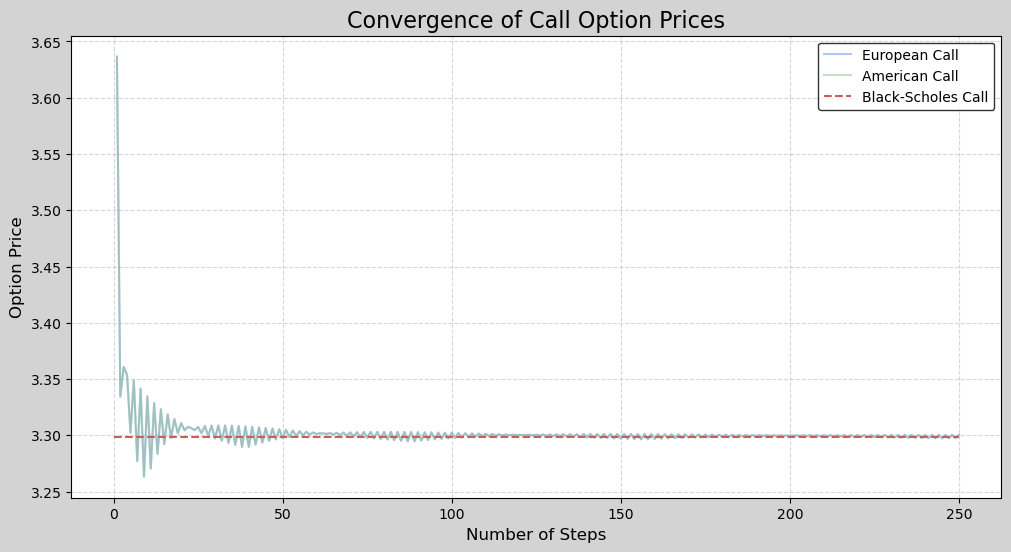

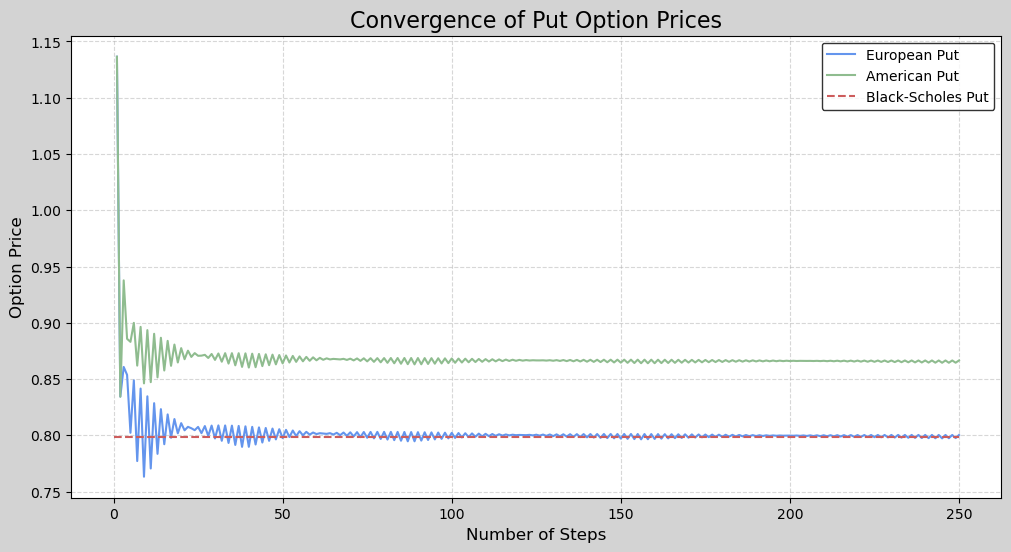

In [9]:
plt.figure()
plt.plot(n_plot, prices_eur_call, color='cornflowerblue', alpha=0.5, label="European Call")
plt.plot(n_plot, prices_ame_call, color='darkseagreen', alpha=0.5, label="American Call")
plt.hlines(bs_c, 0, n_steps, colors='indianred', linestyles='dashed', label="Black-Scholes Call")
plt.title("Convergence of Call Option Prices")
plt.xlabel("Number of Steps")
plt.ylabel("Option Price")
plt.legend()
plt.show()

plt.figure()
plt.plot(n_plot, prices_eur_put, color='cornflowerblue', label="European Put")
plt.plot(n_plot, prices_ame_put, color='darkseagreen', label="American Put")
plt.hlines(bs_p, 0, n_steps, colors='indianred', linestyles='dashed', label="Black-Scholes Put")
plt.title("Convergence of Put Option Prices")
plt.xlabel("Number of Steps")
plt.ylabel("Option Price")
plt.legend()
plt.show()

# Compound Options

In [10]:
# === FINANCIAL OPTIONS === #
def e_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = (np.log(S / K) + (r - 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    call = (S * si.norm.cdf(d1, 0.0, 1.0) - K *
            np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0))
    return call


def e_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = (np.log(S / K) + (r - 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    put = (K * np.exp(-r * T) * si.norm.cdf(-d2, 0.0, 1.0) -
           S * si.norm.cdf(-d1, 0.0, 1.0))
    return put


# === OPTIMAL OPTIONS PRICE === #
def SOpt_call(S, X1, X2, T1, T2, r, sigma):
    tau = T2-T1
    bounds = [[0, None]]
    def apply_constraint1(S): return e_call(S, X2, tau, r, sigma)-X1
    my_constraints = ({'type': 'eq', "fun": apply_constraint1})
    a = minimize(e_call, S, bounds=bounds, constraints=my_constraints,
                 method='SLSQP', args=(X2, tau, r, sigma))
    SOpt = a.x[0]
    return SOpt


def SOpt_put(S, X1, X2, T1, T2, r, sigma):
    tau = T2-T1
    bounds = [[0, None]]
    def apply_constraint1(S): return e_put(S, X2, tau, r, sigma)-X1
    my_constraints = ({'type': 'eq', "fun": apply_constraint1})
    a = minimize(e_put, S, bounds=bounds, constraints=my_constraints,
                 method='SLSQP', args=(X2, tau, r, sigma))
    SOpt = a.x[0]
    return SOpt


# === COMPOUND OPTIONS PRICE === #
def Call_call(S, X1, X2, T1, T2, t, r, sigma):
    SOpt = SOpt_call(S, X1, X2, T1, T2, r, sigma)
    D1 = (np.log(S / SOpt) + (r + 0.5 * sigma ** 2)
          * (T1-t)) / (sigma * np.sqrt(T1-t))
    D2 = D1-sigma*np.sqrt(T1-t)

    E1 = (np.log(S / X2) + (r + 0.5 * sigma ** 2)
          * (T2-t)) / (sigma * np.sqrt(T2-t))
    E2 = E1-sigma*np.sqrt(T2-t)

    Corr = np.sqrt(T1/T2)
    dist = mvn(mean=np.array([0, 0]), cov=np.array([[1, Corr], [Corr, 1]]))
    N2D1E1 = dist.cdf(np.array([D1, E1]))
    N2D2E2 = dist.cdf(np.array([D2, E2]))
    ND2 = si.norm.cdf(D2, 0.0, 1.0)

    Call_call = S*N2D1E1 - X2 * \
        np.exp(-r*(T2-t))*N2D2E2 - X1*np.exp(-r*(T1-t))*ND2
    return Call_call


def Call_put(S, X1, X2, T1, T2, t, r, sigma):
    SOpt = SOpt_put(S, X1, X2, T1, T2, r, sigma)
    D1 = (np.log(S / SOpt) + (r + 0.5 * sigma ** 2)
          * (T1-t)) / (sigma * np.sqrt(T1-t))
    D2 = D1-sigma*np.sqrt(T1-t)

    E1 = (np.log(S / X2) + (r + 0.5 * sigma ** 2)
          * (T2-t)) / (sigma * np.sqrt(T2-t))
    E2 = E1-sigma*np.sqrt(T2-t)

    Corr = np.sqrt(T1/T2)
    dist = mvn(mean=np.array([0, 0]), cov=np.array([[1, Corr], [Corr, 1]]))
    N2_D1_E1 = dist.cdf(np.array([-D1, -E1]))
    N2_D2_E2 = dist.cdf(np.array([-D2, -E2]))
    N_D2 = si.norm.cdf(-D2, 0.0, 1.0)

    Call_put = -S*N2_D1_E1 + X2 * \
        np.exp(-r*(T2-t))*N2_D2_E2 - X1*np.exp(-r*(T1-t))*N_D2
    return Call_put


def Put_call(S, X1, X2, T1, T2, t, r, sigma):
    SOpt = SOpt_call(S, X1, X2, T1, T2, r, sigma)
    D1 = (np.log(S / SOpt) + (r + 0.5 * sigma ** 2)
          * (T1-t)) / (sigma * np.sqrt(T1-t))
    D2 = D1-sigma*np.sqrt(T1-t)

    E1 = (np.log(S / X2) + (r + 0.5 * sigma ** 2)
          * (T2-t)) / (sigma * np.sqrt(T2-t))
    E2 = E1-sigma*np.sqrt(T2-t)

    Corr = np.sqrt(T1/T2)
    dist = mvn(mean=np.array([0, 0]), cov=np.array([[1, -Corr], [-Corr, 1]]))
    N2_D1E1 = dist.cdf(np.array([-D1, E1]))
    N2_D2E2 = dist.cdf(np.array([-D2, E2]))
    N_D2 = si.norm.cdf(-D2, 0.0, 1.0)

    Put_call = -S*N2_D1E1 + X2 * \
        np.exp(-r*(T2-t))*N2_D2E2 - X1*np.exp(-r*(T1-t))*N_D2
    return Put_call


def Put_put(S, X1, X2, T1, T2, t, r, sigma):
    SOpt = SOpt_put(S, X1, X2, T1, T2, r, sigma)
    D1 = (np.log(S / SOpt) + (r + 0.5 * sigma ** 2)
          * (T1-t)) / (sigma * np.sqrt(T1-t))
    D2 = D1-sigma*np.sqrt(T1-t)

    E1 = (np.log(S / X2) + (r + 0.5 * sigma ** 2)
          * (T2-t)) / (sigma * np.sqrt(T2-t))
    E2 = E1-sigma*np.sqrt(T2-t)

    Corr = np.sqrt(T1/T2)
    dist = mvn(mean=np.array([0, 0]), cov=np.array([[1, -Corr], [-Corr, 1]]))
    N2D1_E1 = dist.cdf(np.array([D1, -E1]))
    N2D2_E2 = dist.cdf(np.array([D2, -E2]))
    ND2 = si.norm.cdf(D2, 0.0, 1.0)

    Put_put = -S*N2D1_E1 - X2 * \
        np.exp(-r*(T2-t))*N2D2_E2 + X1*np.exp(-r*(T1-t))*ND2
    return Put_put

In [11]:
S = 200
X2 = 250
r = 0.05
sigma = 0.5
T2=3
T1=2
t=0
X1=20

call_call_price = Call_call(S,X1,X2,T1,T2,t,r,sigma)
call_put_price = Call_put(S,X1,X2,T1,T2,t,r,sigma)
put_call_price = Put_call(S,X1,X2,T1,T2,t,r,sigma)
put_put_price = Put_put(S,X1,X2,T1,T2,t,r,sigma)

print(f'Call-call price ${call_call_price:.4f}')
print(f'Call-put price  ${call_put_price:.4f}')
print(f'Put-call price  ${put_call_price:.4f}')
print(f'Put-put price   ${put_put_price:.4f}')

Call-call price $51.5348
Call-put price  $61.0844
Put-call price  $-12.0233
Put-put price   $-6.8719
